# XAI Gate #1 — Baseline Quality Assessment

**Project:** Customer Churn Prediction  
**Notebook:** 04 — XAI Quality Gate #1  
**Depends on:** `02_preprocessing.ipynb` (splits) + `03_baseline_training.ipynb` (8 model)  
**Referensi:** `xai-quality-gate-ml.md`

---

## Tujuan

Memvalidasi bahwa model tidak hanya punya metrik bagus, tapi **belajar dari alasan yang benar**.
Gate ini mendeteksi **Reasoning Failure (Lapisan 3)** — model dengan metrik bagus
tapi logika keputusannya tidak konsisten dengan domain knowledge churn.

---

## Dimensi yang Dijalankan di Gate #1

| Dimensi | Status | Peran di Gate #1 |
|---|---|---|
| D1 Relevance | **WAJIB** | Penentu lulus/gagal |
| D2 Directionality | **WAJIB** | Penentu lulus/gagal |
| D3 Magnitude | Opsional | Penentu Jalur 1 vs 2 |
| D4 Consistency | Opsional | Penentu Jalur 1 vs 2 |
| D5 Stability | Tidak dijalankan | Tidak relevan di baseline |
| D6 Locality | Tidak dijalankan | Tidak relevan di baseline |
| D7 Error Coherence | Tidak dijalankan | Tidak relevan di baseline |

## Sistem Keputusan 3 Jalur

```
Jalur 1 — Prioritas Tinggi  : Lulus D1 + D2 + D3 + D4 → Optuna 100 trials
Jalur 2 — Bersyarat         : Lulus D1 + D2, gagal D3/D4 → Optuna 30 trials
Jalur 3 — Eliminasi         : Gagal D1 ATAU D2 → tidak masuk tuning
```

## 8 Kandidat yang Dievaluasi

Semua 8 model yang lulus kriteria metrik baseline:
LightGBM (class_weight, SMOTE), XGBoost (class_weight, SMOTE),
Logistic Regression (class_weight, SMOTE), Voting Ensemble (class_weight, SMOTE)

---
## Install & Import

In [1]:
!pip install shap wandb --quiet
print('OK install selesai.')

OK install selesai.


In [2]:
import os, json, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap
from scipy.stats import spearmanr
from sklearn.inspection import permutation_importance
import joblib
import wandb

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)
plt.rcParams['figure.dpi'] = 110
sns.set_theme(style='whitegrid', font_scale=1.05)

print('OK import selesai.')

OK import selesai.


---
## Konstanta Global

In [3]:
# ── Path ──────────────────────────────────────────────────────────────────────
PREPROCESSING_DIR = '/kaggle/input/notebooks/ardiyanto24/tccp-preprocessing-v2/artifacts'
BASELINE_DIR      = '/kaggle/input/notebooks/ardiyanto24/tccp-modeling-baseline-v2/artifacts'
SPLITS_PATH       = f'{PREPROCESSING_DIR}/splits.joblib'
OUTPUT_DIR        = '/kaggle/working/artifacts'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ── WandB ─────────────────────────────────────────────────────────────────────
WANDB_PROJECT   = 'customer-churn-prediction'
WANDB_GATE_GROUP= 'xai-gate-1'

# ── Reproducibility ───────────────────────────────────────────────────────────
RANDOM_SEED = 42

# ── D1: Relevance ─────────────────────────────────────────────────────────────
# Fitur yang diharapkan masuk top-N berdasarkan EDA Insight 65
# Ini adalah PARENT feature names — sebelum OHE
EXPECTED_IMPORTANT_FEATURES = [
    'Contract',
    'tenure',
    'PaymentMethod',
    'InternetService',
    'OnlineSecurity'
]
XAI_TOP_N       = 10    # evaluasi top-10 fitur
XAI_MIN_OVERLAP = 0.50  # minimal 50% = 2 dari 5 harus muncul

# ── D2: Directionality ────────────────────────────────────────────────────────
# Ekspektasi arah SHAP per fitur berdasarkan EDA
# 'positive' = fitur bernilai tinggi/aktif mendorong churn (SHAP > 0)
# 'negative' = fitur bernilai tinggi/aktif menurunkan churn (SHAP < 0)
# None = tidak ada ekspektasi kuat dari EDA, skip check
#
# Dasar EDA:
# - Contract Two year / One year → churn rate 1% / 5.76% vs M2M 42% (Insight 21)
# - tenure tinggi → churn rendah, mean churn=17bln vs no-churn=42bln (Insight 17)
# - Fiber optic → churn rate 41.54% (Insight 22)
# - InternetService=No → churn rate 1.43% (Insight 22)
# - Electronic check → churn rate 48.91% (Insight 23)
# - Auto payment → churn rate 7.30% vs non-auto 33.97% (Insight 42)
# - monthly_to_total_ratio tinggi = pelanggan baru → churn tinggi (Insight 41)
# - tc_residual: arah tidak diprediksi kuat, pola non-linear inverted-V (Insight 64)
# - OnlineSecurity=Yes → churn rate 8.7% vs No 40.6% (Insight 28)
EXPECTED_DIRECTIONS = {
    # Contract OHE — keduanya negative (dibandingkan baseline M2M)
    'Contract_One year'                    : 'negative',
    'Contract_Two year'                    : 'negative',
    # tenure — semakin lama semakin tidak churn
    'tenure'                               : 'negative',
    # tenure_group — G4 (loyal) paling negatif, dibanding G1 baseline
    'tenure_group_G4_44_72'                : 'negative',
    'tenure_group_G3_18_44'                : 'negative',
    'tenure_group_G2_2_18'                 : 'negative',
    # InternetService OHE
    'InternetService_Fiber optic'          : 'positive',   # churn 41.54%
    'InternetService_No'                   : 'negative',   # churn 1.43%
    # PaymentMethod OHE — electronic check paling tinggi churn
    'PaymentMethod_Electronic check'       : 'positive',   # churn 48.91%
    'PaymentMethod_Credit card (automatic)': 'negative',   # churn 6.93%
    'PaymentMethod_Mailed check'           : 'negative',   # churn 7.97%
    # Fitur binary/encoded add-on — punya layanan = loyalitas lebih
    'OnlineSecurity'                       : 'negative',
    'TechSupport'                          : 'negative',
    'OnlineBackup'                         : 'negative',
    'DeviceProtection'                     : 'negative',
    # Feature engineering
    'is_auto_payment'                      : 'negative',   # auto payment → tidak churn
    'monthly_to_total_ratio'               : 'positive',   # ratio tinggi = baru = churn
    'has_any_addon'                        : 'negative',   # punya addon = terikat
    'service_count'                        : 'negative',   # makin banyak addon = makin loyal
    # Demografis
    'SeniorCitizen'                        : 'positive',   # senior churn 50% (Insight 24)
    'Partner'                              : 'negative',   # punya partner churn lebih rendah
    'Dependents'                           : 'negative',   # punya tanggungan churn lebih rendah
    'PaperlessBilling'                     : 'positive',   # paperless churn 31.94% (Insight 27)
    # tc_residual: arah tidak diprediksi — pola non-linear inverted-V
    'tc_residual'                          : None,
    # MonthlyCharges: arah tidak diprediksi kuat di level global
    # (non-monoton: rendah aman, menengah berbahaya, sangat tinggi aman)
    'MonthlyCharges'                       : None,
}

# ── D3: Magnitude thresholds ──────────────────────────────────────────────────
D3_DOMINANCE_RATIO_MAX = 3.0   # top/second > 3.0 = terlalu dominan (rapuh)
D3_FLATNESS_CV_MIN     = 0.10  # std/mean < 0.10 = terlalu flat (noise averaging)

# ── D4: Consistency threshold ─────────────────────────────────────────────────
D4_SPEARMAN_MIN = 0.70  # rata-rata Spearman antar 3 metode > 0.70 = konsisten

# ── 8 Kandidat model ─────────────────────────────────────────────────────────
CANDIDATES = [
    {'model_name': 'lightgbm',            'balance': 'class_weight', 'tier': 1,
     'val_pr_auc': 0.7514},
    {'model_name': 'xgboost',             'balance': 'class_weight', 'tier': 1,
     'val_pr_auc': 0.7512},
    {'model_name': 'xgboost',             'balance': 'smote',        'tier': 1,
     'val_pr_auc': 0.7479},
    {'model_name': 'lightgbm',            'balance': 'smote',        'tier': 1,
     'val_pr_auc': 0.7464},
    {'model_name': 'logistic_regression', 'balance': 'class_weight', 'tier': 2,
     'val_pr_auc': 0.7410},
    {'model_name': 'logistic_regression', 'balance': 'smote',        'tier': 2,
     'val_pr_auc': 0.7407},
]

print('OK konstanta global terdefinisi.')
print(f'   EXPECTED_IMPORTANT_FEATURES : {EXPECTED_IMPORTANT_FEATURES}')
print(f'   XAI_TOP_N                   : {XAI_TOP_N}')
print(f'   XAI_MIN_OVERLAP             : {XAI_MIN_OVERLAP} ({int(XAI_MIN_OVERLAP*len(EXPECTED_IMPORTANT_FEATURES))}/{len(EXPECTED_IMPORTANT_FEATURES)} fitur)')
print(f'   D3_DOMINANCE_RATIO_MAX      : {D3_DOMINANCE_RATIO_MAX}')
print(f'   D4_SPEARMAN_MIN             : {D4_SPEARMAN_MIN}')
print(f'   Jumlah kandidat             : {len(CANDIDATES)}')

OK konstanta global terdefinisi.
   EXPECTED_IMPORTANT_FEATURES : ['Contract', 'tenure', 'PaymentMethod', 'InternetService', 'OnlineSecurity']
   XAI_TOP_N                   : 10
   XAI_MIN_OVERLAP             : 0.5 (2/5 fitur)
   D3_DOMINANCE_RATIO_MAX      : 3.0
   D4_SPEARMAN_MIN             : 0.7
   Jumlah kandidat             : 6


---
## Deklarasi Class & Function

> Semua class bersifat stateless — tidak ada state yang perlu di-fit.
> Setiap method menerima data dan mengembalikan hasil analisis.

In [4]:
# ══════════════════════════════════════════════════════════════════════════════
# CLASS: ParentFeatureMapper
# Tanggung jawab: mapping nama fitur OHE kembali ke parent feature aslinya
# Diperlukan untuk D1 Relevance check
# ══════════════════════════════════════════════════════════════════════════════

class ParentFeatureMapper:
    '''
    Setelah OHE, nama fitur menjadi:
      Contract_One year, Contract_Two year  → parent: Contract
      InternetService_Fiber optic           → parent: InternetService
      tenure_group_G1_0_2                   → parent: tenure_group
      dst.

    Fitur yang tidak punya prefix OHE (tenure, MonthlyCharges, dll)
    di-return as-is.
    '''

    # Prefix OHE yang dikenal — urutan penting (lebih spesifik dulu)
    OHE_PARENTS = [
        'Contract',
        'InternetService',
        'PaymentMethod',
        'tenure_group',
        'MultipleLines',
    ]

    @classmethod
    def to_parent(cls, feature_name: str) -> str:
        for parent in cls.OHE_PARENTS:
            if feature_name.startswith(f'{parent}_'):
                return parent
        return feature_name

    @classmethod
    def map_list(cls, feature_names: list) -> list:
        return [cls.to_parent(f) for f in feature_names]

    @classmethod
    def top_n_parents(cls, shap_importance: pd.Series, n: int) -> list:
        '''
        Dari SHAP importance series (indexed by feature name),
        kembalikan top-N parent feature names (deduplicated).
        Jika satu parent punya beberapa OHE column, ambil max importance-nya.
        '''
        df = shap_importance.reset_index()
        df.columns = ['feature', 'importance']
        df['parent'] = df['feature'].apply(cls.to_parent)
        parent_imp = df.groupby('parent')['importance'].max().sort_values(ascending=False)
        return parent_imp.head(n).index.tolist()


print('OK ParentFeatureMapper terdefinisi.')

OK ParentFeatureMapper terdefinisi.


In [5]:
# ══════════════════════════════════════════════════════════════════════════════
# CLASS: SHAPComputer
# Tanggung jawab: compute SHAP values untuk berbagai tipe model
# - TreeExplainer : XGBoost, LightGBM, RandomForest
# - LinearExplainer: Logistic Regression
# - VotingEnsemble: average SHAP dari base estimators
# ══════════════════════════════════════════════════════════════════════════════

class SHAPComputer:
    '''
    Compute SHAP values dengan explainer yang tepat per model type.

    TreeExplainer (XGBoost, LightGBM, RF):
      Exact Shapley values menggunakan tree structure.
      Tidak membutuhkan background dataset.

    LinearExplainer (Logistic Regression):
      Exact Shapley values untuk model linear.
      Menggunakan interventional perturbation dengan background sample.

    VotingEnsemble:
      Tidak ada TreeExplainer untuk VotingClassifier secara langsung.
      Strategi: compute SHAP untuk masing-masing base estimator
      (xgb, lgbm, rf) lalu average — konsisten dengan cara soft voting
      menghasilkan probabilitas final.
    '''

    TREE_BASED_NAMES = ['xgboost', 'lightgbm', 'random_forest']
    LR_NAMES         = ['logistic_regression']
    ENSEMBLE_NAMES   = ['voting_ensemble']

    @staticmethod
    def _get_explainer_type(model_name: str) -> str:
        if model_name in SHAPComputer.TREE_BASED_NAMES:
            return 'tree'
        elif model_name in SHAPComputer.LR_NAMES:
            return 'linear'
        elif model_name in SHAPComputer.ENSEMBLE_NAMES:
            return 'ensemble'
        raise ValueError(f'Unknown model type: {model_name}')

    @staticmethod
    def compute(model, model_name: str, X: np.ndarray,
                feature_names: list,
                background_sample: np.ndarray = None) -> np.ndarray:
        '''
        Compute SHAP values.

        Returns
        -------
        shap_values : np.ndarray shape (n_samples, n_features)
            SHAP values untuk kelas positif (churn=1)
        '''
        etype = SHAPComputer._get_explainer_type(model_name)

        if etype == 'tree':
            explainer   = shap.TreeExplainer(model)
            shap_output = explainer.shap_values(X)
            # XGBoost/LGBM mengembalikan array 2D untuk binary
            # RF mengembalikan list [class0, class1]
            if isinstance(shap_output, list):
                return shap_output[1]   # ambil kelas positif
            return shap_output

        elif etype == 'linear':
            # LinearExplainer butuh background data
            if background_sample is None:
                np.random.seed(42)
                idx = np.random.choice(len(X), size=min(1000, len(X)), replace=False)
                background_sample = X[idx]
            masker      = shap.maskers.Independent(background_sample)
            explainer   = shap.LinearExplainer(model, masker)
            shap_output = explainer.shap_values(X)
            # LinearExplainer untuk binary mengembalikan array 2D
            if isinstance(shap_output, list):
                return shap_output[1]
            return shap_output

        elif etype == 'ensemble':
            # Sample untuk efisiensi — RF TreeExplainer sangat lambat di data besar
            np.random.seed(42)
            n_sample = min(10_000, len(X))
            idx      = np.random.choice(len(X), size=n_sample, replace=False)
            X_sample = X[idx]
            
            all_shap = []
            for base_model in model.estimators_:   # sudah benar (tanpa name)
                exp = shap.TreeExplainer(base_model)
                sv  = exp.shap_values(X_sample)
                if isinstance(sv, list):
                    sv = sv[1]
                all_shap.append(sv)
            return np.mean(all_shap, axis=0)


print('OK SHAPComputer terdefinisi.')

OK SHAPComputer terdefinisi.


In [6]:
# ══════════════════════════════════════════════════════════════════════════════
# CLASS: D1RelevanceChecker
# Dimensi 1 — Relevance: apakah fitur yang benar masuk top-N?
# ══════════════════════════════════════════════════════════════════════════════

class D1RelevanceChecker:
    '''
    Hitung overlap antara EXPECTED_IMPORTANT_FEATURES dengan
    actual top-N parent features dari SHAP importance.

    Threshold: minimal XAI_MIN_OVERLAP (50%) expected features
    harus muncul di top-N.
    '''

    def __init__(self,
                 expected: list       = None,
                 top_n: int           = XAI_TOP_N,
                 min_overlap: float   = XAI_MIN_OVERLAP):
        self.expected    = expected    or EXPECTED_IMPORTANT_FEATURES
        self.top_n       = top_n
        self.min_overlap = min_overlap

    def check(self, shap_values: np.ndarray,
              feature_names: list,
              verbose: bool = True) -> dict:
        # Hitung mean |SHAP| per fitur
        mean_abs_shap = pd.Series(
            np.abs(shap_values).mean(axis=0),
            index=feature_names
        ).sort_values(ascending=False)

        # Ambil top-N parent features
        top_n_parents = ParentFeatureMapper.top_n_parents(mean_abs_shap, self.top_n)

        # Hitung overlap
        found    = [f for f in self.expected if f in top_n_parents]
        missing  = [f for f in self.expected if f not in top_n_parents]
        overlap  = len(found) / len(self.expected)
        passed   = overlap >= self.min_overlap

        if verbose:
            print(f'  D1 — RELEVANCE')
            print(f'    Top-{self.top_n} parent features: {top_n_parents}')
            print(f'    Expected features    : {self.expected}')
            print(f'    Found ({len(found)}/{len(self.expected)})         : {found}')
            if missing:
                print(f'    Missing              : {missing}')
            print(f'    Overlap              : {overlap:.0%} (threshold {self.min_overlap:.0%})')
            print(f'    Verdict              : {"PASS" if passed else "FAIL"}')

        return {
            'passed'         : passed,
            'overlap_pct'    : overlap,
            'found_features' : found,
            'missing_features': missing,
            'top_n_parents'  : top_n_parents,
            'shap_importance': mean_abs_shap,
        }


print('OK D1RelevanceChecker terdefinisi.')

OK D1RelevanceChecker terdefinisi.


In [7]:
# ══════════════════════════════════════════════════════════════════════════════
# CLASS: D2DirectionalityChecker
# Dimensi 2 — Directionality: arah SHAP konsisten dengan domain knowledge?
# ══════════════════════════════════════════════════════════════════════════════

class D2DirectionalityChecker:
    '''
    Untuk setiap fitur yang ada di EXPECTED_DIRECTIONS:
    1. Hitung korelasi Spearman antara nilai fitur dan SHAP values-nya
    2. Bandingkan arah korelasi dengan ekspektasi EDA

    Logika:
    - Fitur binary (0/1): korelasi positif antara nilai fitur dan SHAP
      berarti nilai=1 mendorong prediksi ke arah positif (churn)
    - Fitur kontinu: korelasi positif berarti nilai tinggi → SHAP positif

    Catatan penting:
    - Fitur dengan expected_direction=None di-skip (tidak dihukum)
    - Fitur yang tidak ada di feature_names di-skip
    - Hanya fitur yang masuk top-N yang dievaluasi (yang tidak masuk
      mungkin memang tidak berpengaruh dan SHAP-nya mendekati nol)
    '''

    def __init__(self, expected_directions: dict = None):
        self.expected_directions = expected_directions or EXPECTED_DIRECTIONS

    def check(self, shap_values: np.ndarray,
              X: np.ndarray,
              feature_names: list,
              top_n_features: list = None,
              verbose: bool = True) -> dict:
        '''
        Parameters
        ----------
        top_n_features : list, optional
            Jika diberikan, hanya evaluasi fitur yang ada di top-N ini.
            Fitur di luar top-N SHAP-nya mendekati nol — arahnya tidak bermakna.
        '''
        results      = []
        violations   = []
        feat_idx_map = {f: i for i, f in enumerate(feature_names)}

        for feat, expected_dir in self.expected_directions.items():
            if expected_dir is None:
                continue
            if feat not in feat_idx_map:
                continue
            # Hanya evaluasi fitur yang ada di top-N (opsional)
            if top_n_features and feat not in top_n_features:
                continue

            idx         = feat_idx_map[feat]
            feat_values = X[:, idx]
            shap_vals   = shap_values[:, idx]

            # Spearman correlation antara feature value dan SHAP
            corr, pval  = spearmanr(feat_values, shap_vals)
            actual_dir  = 'positive' if corr > 0 else 'negative'
            direction_ok= (actual_dir == expected_dir)

            results.append({
                'feature'     : feat,
                'expected_dir': expected_dir,
                'actual_dir'  : actual_dir,
                'spearman_r'  : round(corr, 4),
                'pass'        : direction_ok
            })
            if not direction_ok:
                violations.append(feat)

        n_checked  = len(results)
        n_pass     = sum(r['pass'] for r in results)
        passed     = len(violations) == 0

        if verbose:
            print(f'  D2 — DIRECTIONALITY')
            print(f'    Fitur dievaluasi: {n_checked}')
            for r in results:
                icon = 'OK' if r['pass'] else 'VIOLATION'
                print(f'    [{icon:9s}] {r["feature"]:40s} '
                      f'expected={r["expected_dir"]:8s} actual={r["actual_dir"]:8s} '
                      f'r={r["spearman_r"]:+.4f}')
            print(f'    Pass: {n_pass}/{n_checked}')
            if violations:
                print(f'    Violations: {violations}')
            print(f'    Verdict: {"PASS" if passed else "FAIL"}')

        return {
            'passed'     : passed,
            'n_checked'  : n_checked,
            'n_pass'     : n_pass,
            'violations' : violations,
            'details'    : results
        }


print('OK D2DirectionalityChecker terdefinisi.')

OK D2DirectionalityChecker terdefinisi.


In [8]:
# ══════════════════════════════════════════════════════════════════════════════
# CLASS: D3MagnitudeChecker
# Dimensi 3 — Magnitude: distribusi besar pengaruh fitur masuk akal?
# ══════════════════════════════════════════════════════════════════════════════

class D3MagnitudeChecker:
    '''
    Dua failure signal:

    1. Dominance: satu fitur mendominasi dengan gap ekstrem
       top_importance / second_importance > D3_DOMINANCE_RATIO_MAX
       → model terlalu bergantung satu sinyal, rapuh di production

    2. Flatness: semua fitur punya magnitude sangat mirip
       coefficient_of_variation (std/mean) dari top-N < D3_FLATNESS_CV_MIN
       → model hanya averaging noise, tidak menemukan sinyal dominan
    '''

    def __init__(self,
                 dominance_ratio_max: float = D3_DOMINANCE_RATIO_MAX,
                 flatness_cv_min: float     = D3_FLATNESS_CV_MIN,
                 top_n: int                 = XAI_TOP_N):
        self.dominance_ratio_max = dominance_ratio_max
        self.flatness_cv_min     = flatness_cv_min
        self.top_n               = top_n

    def check(self, shap_importance: pd.Series, verbose: bool = True) -> dict:
        top_n_imp  = shap_importance.head(self.top_n)
        vals       = top_n_imp.values

        # Dominance check
        if len(vals) >= 2:
            dom_ratio   = vals[0] / vals[1] if vals[1] > 0 else float('inf')
            dom_fail    = dom_ratio > self.dominance_ratio_max
        else:
            dom_ratio, dom_fail = 0.0, False

        # Flatness check
        mean_imp     = vals.mean()
        std_imp      = vals.std()
        cv           = std_imp / mean_imp if mean_imp > 0 else 0
        flat_fail    = cv < self.flatness_cv_min

        passed       = not dom_fail and not flat_fail

        if verbose:
            print(f'  D3 — MAGNITUDE')
            print(f'    Top feature       : {top_n_imp.index[0]} ({vals[0]:.4f})')
            if len(vals) >= 2:
                print(f'    2nd feature       : {top_n_imp.index[1]} ({vals[1]:.4f})')
            print(f'    Dominance ratio   : {dom_ratio:.2f} (max {self.dominance_ratio_max})')
            print(f'    CV (std/mean)     : {cv:.4f} (min {self.flatness_cv_min})')
            dom_status  = 'FAIL — terlalu dominan' if dom_fail else 'OK'
            flat_status = 'FAIL — terlalu flat'   if flat_fail else 'OK'
            print(f'    Dominance check   : {dom_status}')
            print(f'    Flatness check    : {flat_status}')
            print(f'    Verdict           : {"PASS" if passed else "FAIL"}')

        return {
            'passed'       : passed,
            'dominance_ratio': dom_ratio,
            'cv'           : cv,
            'dom_fail'     : dom_fail,
            'flat_fail'    : flat_fail
        }


print('OK D3MagnitudeChecker terdefinisi.')

OK D3MagnitudeChecker terdefinisi.


In [9]:
# ══════════════════════════════════════════════════════════════════════════════
# CLASS: D4ConsistencyChecker
# Dimensi 4 — Consistency: tiga metode XAI sepakat?
# ══════════════════════════════════════════════════════════════════════════════

class D4ConsistencyChecker:
    '''
    Bandingkan ranking tiga metode XAI:
    1. SHAP importance (mean |SHAP values|)
    2. Permutation Importance (sklearn)
    3. Built-in importance:
       - Tree-based: feature_importances_
       - Logistic Regression: |coef_| sebagai proxy

    Cara ukur: Spearman rank correlation antar pasangan ranking.
    Ada 3 pasangan: SHAP-PI, SHAP-BI, PI-BI.
    Passed jika rata-rata Spearman >= D4_SPEARMAN_MIN.

    Catatan dari dokumen:
    "inkonsistensi di baseline bisa berasal dari underfitting"
    D4 hanya mempengaruhi Jalur 1 vs 2, tidak penentu lulus/gagal.
    '''

    def __init__(self, spearman_min: float = D4_SPEARMAN_MIN):
        self.spearman_min = spearman_min

    def _get_builtin_importance(self, model, model_name: str,
                                 feature_names: list) -> pd.Series:
        if model_name == 'logistic_regression':
            # |coef_| sebagai proxy built-in importance
            imp = np.abs(model.coef_[0])
        elif model_name == 'voting_ensemble':
            # Average feature_importances_ dari base tree estimators
            all_imp = []
            for est in model.estimators_:
                if hasattr(est, 'feature_importances_'):
                    all_imp.append(est.feature_importances_)
            imp = np.mean(all_imp, axis=0) if all_imp else np.zeros(len(feature_names))
        else:
            imp = model.feature_importances_
        return pd.Series(imp, index=feature_names).sort_values(ascending=False)

    def check(self, model, model_name: str,
              shap_values: np.ndarray,
              X_val: np.ndarray, y_val: np.ndarray,
              feature_names: list,
              verbose: bool = True) -> dict:

        # 1. SHAP importance
        shap_imp = pd.Series(
            np.abs(shap_values).mean(axis=0),
            index=feature_names
        ).sort_values(ascending=False)

        # 2. Permutation Importance (val set, scoring=average_precision)
        if model_name == 'voting_ensemble' and len(X_val) > 10_000:
            np.random.seed(RANDOM_SEED)
            pi_idx   = np.random.choice(len(X_val), size=10_000, replace=False)
            X_pi     = X_val[pi_idx]
            y_pi     = y_val[pi_idx]
        else:
            X_pi, y_pi = X_val, y_val
        
        pi_result = permutation_importance(
            model, X_pi, y_pi,        # ← gunakan sample
            n_repeats=10,
            random_state=RANDOM_SEED,
            scoring='average_precision',
            n_jobs=-1
        )
        pi_imp = pd.Series(
            pi_result.importances_mean,
            index=feature_names
        ).sort_values(ascending=False)

        # 3. Built-in importance
        bi_imp = self._get_builtin_importance(model, model_name, feature_names)

        # Hitung Spearman rank correlation antar pasangan
        # Align semua ke urutan yang sama sebelum korelasi
        common_idx = shap_imp.index
        shap_ranks = shap_imp.rank(ascending=False)
        pi_ranks   = pi_imp.reindex(common_idx).rank(ascending=False)
        bi_ranks   = bi_imp.reindex(common_idx).rank(ascending=False)

        corr_shap_pi, _ = spearmanr(shap_ranks, pi_ranks)
        corr_shap_bi, _ = spearmanr(shap_ranks, bi_ranks)
        corr_pi_bi,   _ = spearmanr(pi_ranks,   bi_ranks)

        mean_corr = np.mean([corr_shap_pi, corr_shap_bi, corr_pi_bi])
        passed    = mean_corr >= self.spearman_min

        if verbose:
            print(f'  D4 — CONSISTENCY')
            print(f'    Spearman SHAP vs PI : {corr_shap_pi:.4f}')
            print(f'    Spearman SHAP vs BI : {corr_shap_bi:.4f}')
            print(f'    Spearman PI   vs BI : {corr_pi_bi:.4f}')
            print(f'    Mean Spearman       : {mean_corr:.4f} (threshold {self.spearman_min})')
            print(f'    Verdict             : {"PASS" if passed else "FAIL"}')

        return {
            'passed'          : passed,
            'mean_spearman'   : mean_corr,
            'corr_shap_pi'    : corr_shap_pi,
            'corr_shap_bi'    : corr_shap_bi,
            'corr_pi_bi'      : corr_pi_bi,
            'shap_importance' : shap_imp,
            'pi_importance'   : pi_imp,
            'bi_importance'   : bi_imp,
        }


print('OK D4ConsistencyChecker terdefinisi.')

OK D4ConsistencyChecker terdefinisi.


In [10]:
# ══════════════════════════════════════════════════════════════════════════════
# CLASS: XAIGateScorecard
# Tanggung jawab: tentukan jalur berdasarkan hasil D1-D4
# ══════════════════════════════════════════════════════════════════════════════

class XAIGateScorecard:
    '''
    Sistem keputusan 3 jalur:

    Jalur 1 — Prioritas Tinggi
      Syarat: Lulus D1 + D2 + D3 + D4
      Konsekuensi: Optuna 100 trials

    Jalur 2 — Bersyarat
      Syarat: Lulus D1 + D2, gagal D3 atau D4
      Konsekuensi: Optuna 30 trials
        → Jika XAI membaik: lanjut 100 trials
        → Jika tetap bermasalah: eliminasi

    Jalur 3 — Eliminasi
      Syarat: Gagal D1 ATAU D2
      Konsekuensi: tidak masuk tuning
    '''

    @staticmethod
    def decide(d1_passed: bool, d2_passed: bool,
               d3_passed: bool, d4_passed: bool) -> dict:
        # Jalur 3 — eliminasi
        if not d1_passed or not d2_passed:
            jalur       = 3
            label       = 'ELIMINASI'
            optuna_trials = 0
            keterangan  = 'Masalah struktural. Tuning tidak akan memperbaiki.'
        # Jalur 1 — prioritas tinggi
        elif d3_passed and d4_passed:
            jalur       = 1
            label       = 'PRIORITAS TINGGI'
            optuna_trials = 100
            keterangan  = 'Semua dimensi lulus. Budget tuning penuh.'
        # Jalur 2 — bersyarat
        else:
            jalur       = 2
            label       = 'BERSYARAT'
            optuna_trials = 30
            keterangan  = (
                f'D1+D2 lulus. '
                f'{"D3 gagal. " if not d3_passed else ""}'
                f'{"D4 gagal. " if not d4_passed else ""}'
                f'Budget tuning terbatas (30 trials).'
            )

        return {
            'jalur'        : jalur,
            'label'        : label,
            'optuna_trials': optuna_trials,
            'keterangan'   : keterangan
        }


print('OK XAIGateScorecard terdefinisi.')
print()
print('OK Semua class terdefinisi. Siap eksekusi.')

OK XAIGateScorecard terdefinisi.

OK Semua class terdefinisi. Siap eksekusi.


---
## Load Artifacts

In [11]:
# ── Load preprocessed splits ──────────────────────────────────────────────────
print('Loading splits...')
splits        = joblib.load(SPLITS_PATH)
X_val         = splits['X_val']    # shape (89129, 29)
y_val         = splits['y_val']
feature_names = splits['feature_names']

print(f'  X_val shape    : {X_val.shape}')
print(f'  y_val churn=1  : {y_val.sum():,} ({y_val.mean()*100:.1f}%)')
print(f'  Feature names  : {len(feature_names)} fitur')

# ── Konfirmasi feature names sesuai ekspektasi preprocessing v2 ───────────────
expected_new = ['tc_residual', 'tenure_group_G2_2_18', 'has_any_addon']
for feat in expected_new:
    status = 'OK' if feat in feature_names else 'TIDAK ADA'
    print(f'  [{status}] {feat}')

Loading splits...
  X_val shape    : (89129, 29)
  y_val churn=1  : 20,072 (22.5%)
  Feature names  : 29 fitur
  [OK] tc_residual
  [OK] tenure_group_G2_2_18
  [OK] has_any_addon


In [12]:
# ── Load semua 8 model dari baseline ─────────────────────────────────────────
print('Loading baseline models...')
loaded_models = {}

for cand in CANDIDATES:
    mname   = cand['model_name']
    balance = cand['balance']
    key     = f'{mname}__{balance}'
    fname   = f'{key}.joblib'
    fpath   = os.path.join(BASELINE_DIR, fname)

    if os.path.exists(fpath):
        loaded_models[key] = joblib.load(fpath)
        print(f'  OK {fname}')
    else:
        print(f'  NOT FOUND: {fpath}')

print(f'\nTotal model loaded: {len(loaded_models)}/{len(CANDIDATES)}')

Loading baseline models...
  OK lightgbm__class_weight.joblib
  OK xgboost__class_weight.joblib
  OK xgboost__smote.joblib
  OK lightgbm__smote.joblib
  OK logistic_regression__class_weight.joblib
  OK logistic_regression__smote.joblib

Total model loaded: 6/6


---
## Eksekusi XAI Gate #1

Setiap model dievaluasi secara berurutan:
SHAP computation → D1 → D2 → D3 → D4 → Scorecard → Visualisasi

In [13]:
# ── Inisialisasi checker instances ───────────────────────────────────────────
d1_checker = D1RelevanceChecker()
d2_checker = D2DirectionalityChecker()
d3_checker = D3MagnitudeChecker()
d4_checker = D4ConsistencyChecker()

gate_results = []   # kumpulkan hasil semua model

print('OK Checker instances siap.')

OK Checker instances siap.



  Model: lightgbm__class_weight  [Tier 1]  val_PR-AUC=0.7514
  Computing SHAP values...
  SHAP done dalam 196.5s | shape=(89129, 29)

  D1 — RELEVANCE
    Top-10 parent features: ['Contract', 'PaymentMethod', 'tenure', 'InternetService', 'MonthlyCharges', 'PaperlessBilling', 'MultipleLines', 'monthly_to_total_ratio', 'Dependents', 'StreamingTV']
    Expected features    : ['Contract', 'tenure', 'PaymentMethod', 'InternetService', 'OnlineSecurity']
    Found (4/5)         : ['Contract', 'tenure', 'PaymentMethod', 'InternetService']
    Missing              : ['OnlineSecurity']
    Overlap              : 80% (threshold 50%)
    Verdict              : PASS

  D2 — DIRECTIONALITY
    Fitur dievaluasi: 8
    [OK       ] Contract_One year                        expected=negative actual=negative r=-0.6701
    [OK       ] Contract_Two year                        expected=negative actual=negative r=-0.8034
    [OK       ] tenure                                   expected=negative actual=negati

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ut

  D4 — CONSISTENCY
    Spearman SHAP vs PI : 0.9463
    Spearman SHAP vs BI : 0.6277
    Spearman PI   vs BI : 0.6851
    Mean Spearman       : 0.7530 (threshold 0.7)
    Verdict             : PASS

  SCORECARD  →  JALUR 1: PRIORITAS TINGGI
  Optuna trials: 100
  Keterangan   : Semua dimensi lulus. Budget tuning penuh.


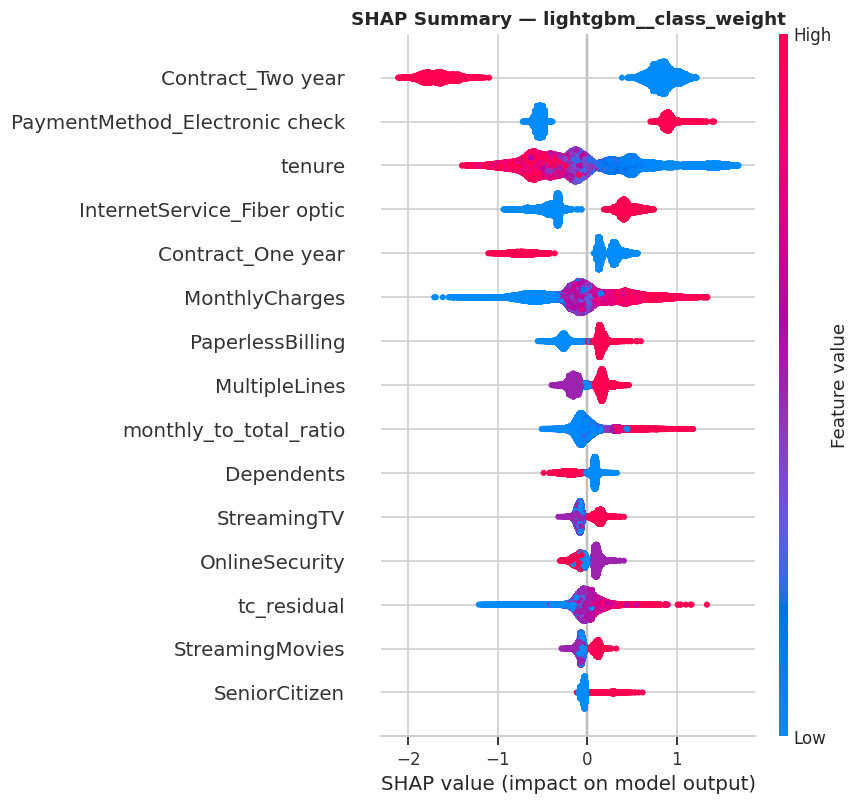


  Model: xgboost__class_weight  [Tier 1]  val_PR-AUC=0.7512
  Computing SHAP values...
  SHAP done dalam 141.6s | shape=(89129, 29)

  D1 — RELEVANCE
    Top-10 parent features: ['Contract', 'PaymentMethod', 'tenure', 'InternetService', 'MonthlyCharges', 'PaperlessBilling', 'monthly_to_total_ratio', 'MultipleLines', 'tc_residual', 'StreamingTV']
    Expected features    : ['Contract', 'tenure', 'PaymentMethod', 'InternetService', 'OnlineSecurity']
    Found (4/5)         : ['Contract', 'tenure', 'PaymentMethod', 'InternetService']
    Missing              : ['OnlineSecurity']
    Overlap              : 80% (threshold 50%)
    Verdict              : PASS

  D2 — DIRECTIONALITY
    Fitur dievaluasi: 7
    [OK       ] Contract_One year                        expected=negative actual=negative r=-0.6701
    [OK       ] Contract_Two year                        expected=negative actual=negative r=-0.8034
    [OK       ] tenure                                   expected=negative actual=negati

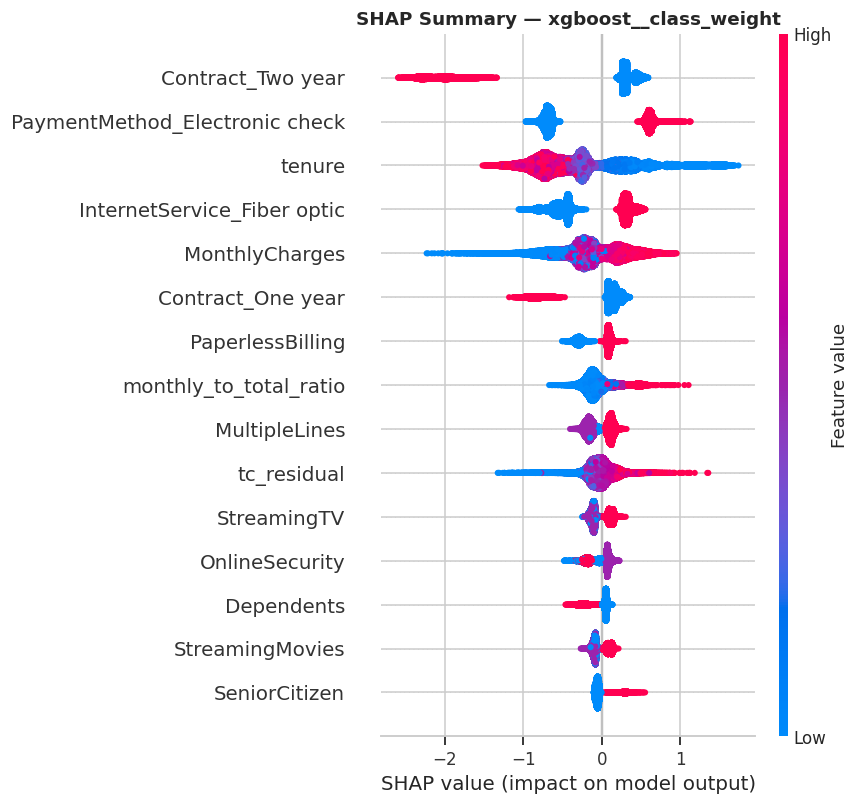


  Model: xgboost__smote  [Tier 1]  val_PR-AUC=0.7479
  Computing SHAP values...
  SHAP done dalam 104.9s | shape=(89129, 29)

  D1 — RELEVANCE
    Top-10 parent features: ['Contract', 'tenure', 'PaymentMethod', 'InternetService', 'MonthlyCharges', 'PaperlessBilling', 'MultipleLines', 'OnlineSecurity', 'Dependents', 'tc_residual']
    Expected features    : ['Contract', 'tenure', 'PaymentMethod', 'InternetService', 'OnlineSecurity']
    Found (5/5)         : ['Contract', 'tenure', 'PaymentMethod', 'InternetService', 'OnlineSecurity']
    Overlap              : 100% (threshold 50%)
    Verdict              : PASS

  D2 — DIRECTIONALITY
    Fitur dievaluasi: 8
    [OK       ] Contract_One year                        expected=negative actual=negative r=-0.6701
    [OK       ] Contract_Two year                        expected=negative actual=negative r=-0.8034
    [OK       ] tenure                                   expected=negative actual=negative r=-0.9303
    [OK       ] InternetServic

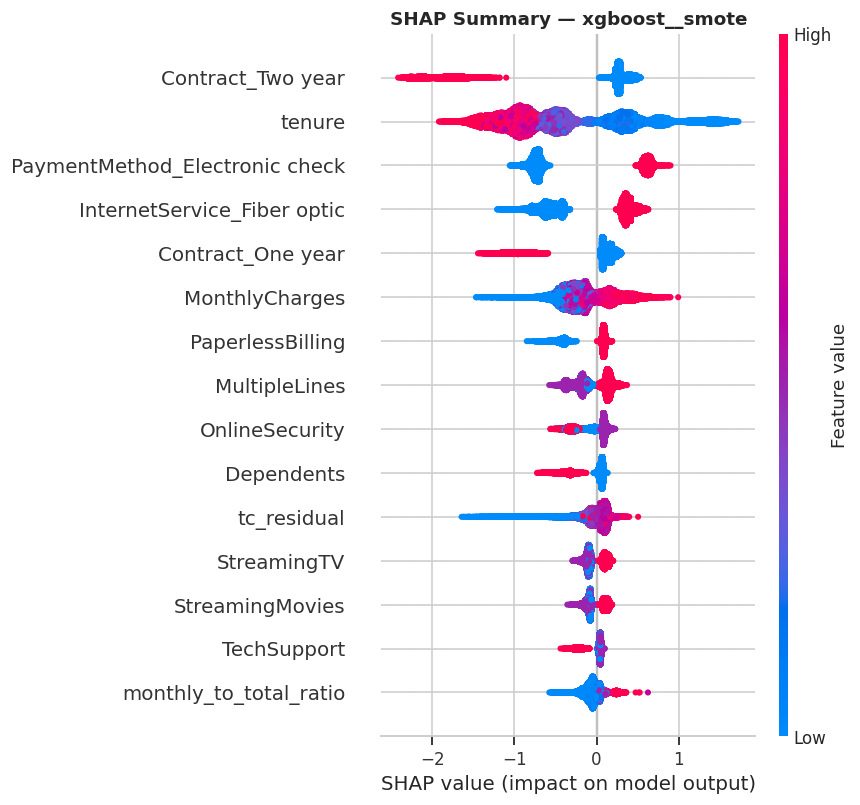


  Model: lightgbm__smote  [Tier 1]  val_PR-AUC=0.7464
  Computing SHAP values...
  SHAP done dalam 171.1s | shape=(89129, 29)

  D1 — RELEVANCE
    Top-10 parent features: ['Contract', 'tenure', 'PaymentMethod', 'InternetService', 'MonthlyCharges', 'PaperlessBilling', 'MultipleLines', 'Dependents', 'tc_residual', 'monthly_to_total_ratio']
    Expected features    : ['Contract', 'tenure', 'PaymentMethod', 'InternetService', 'OnlineSecurity']
    Found (4/5)         : ['Contract', 'tenure', 'PaymentMethod', 'InternetService']
    Missing              : ['OnlineSecurity']
    Overlap              : 80% (threshold 50%)
    Verdict              : PASS

  D2 — DIRECTIONALITY
    Fitur dievaluasi: 7
    [OK       ] Contract_One year                        expected=negative actual=negative r=-0.6701
    [OK       ] Contract_Two year                        expected=negative actual=negative r=-0.8034
    [OK       ] tenure                                   expected=negative actual=negative r=-0

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ut

  D4 — CONSISTENCY
    Spearman SHAP vs PI : 0.9355
    Spearman SHAP vs BI : 0.7429
    Spearman PI   vs BI : 0.6251
    Mean Spearman       : 0.7678 (threshold 0.7)
    Verdict             : PASS

  SCORECARD  →  JALUR 1: PRIORITAS TINGGI
  Optuna trials: 100
  Keterangan   : Semua dimensi lulus. Budget tuning penuh.


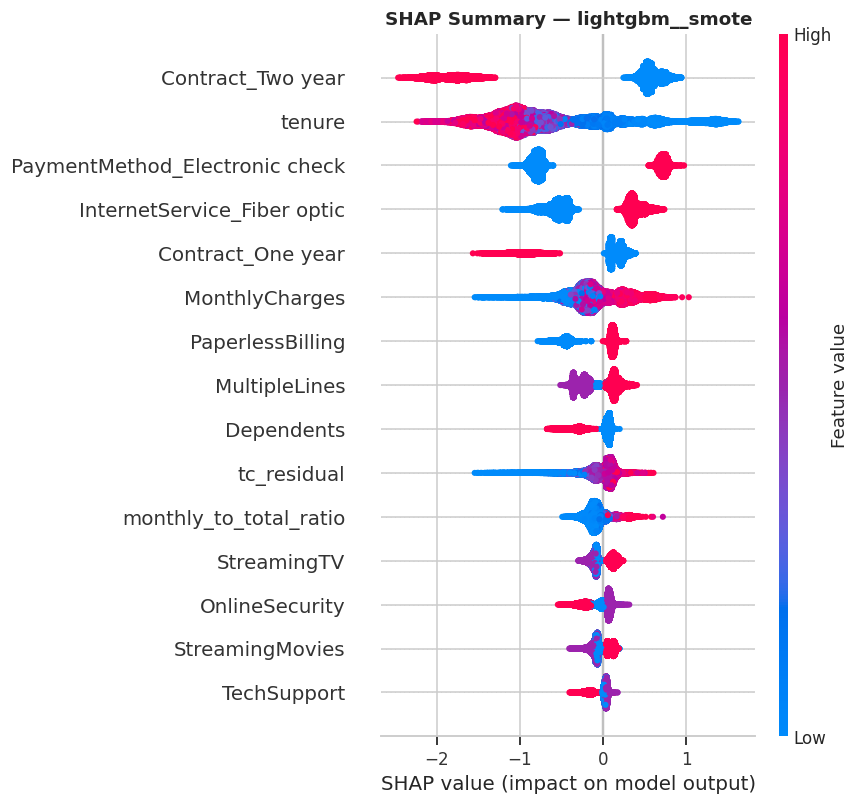


  Model: logistic_regression__class_weight  [Tier 2]  val_PR-AUC=0.741
  Computing SHAP values...
  SHAP done dalam 0.0s | shape=(89129, 29)

  D1 — RELEVANCE
    Top-10 parent features: ['Contract', 'InternetService', 'tenure_group', 'StreamingTV', 'StreamingMovies', 'tenure', 'PaymentMethod', 'service_count', 'PaperlessBilling', 'MultipleLines']
    Expected features    : ['Contract', 'tenure', 'PaymentMethod', 'InternetService', 'OnlineSecurity']
    Found (4/5)         : ['Contract', 'tenure', 'PaymentMethod', 'InternetService']
    Missing              : ['OnlineSecurity']
    Overlap              : 80% (threshold 50%)
    Verdict              : PASS

  D2 — DIRECTIONALITY
    Fitur dievaluasi: 8
    [OK       ] Contract_One year                        expected=negative actual=negative r=-1.0000
    [OK       ] Contract_Two year                        expected=negative actual=negative r=-1.0000
    [OK       ] tenure                                   expected=negative actual=nega

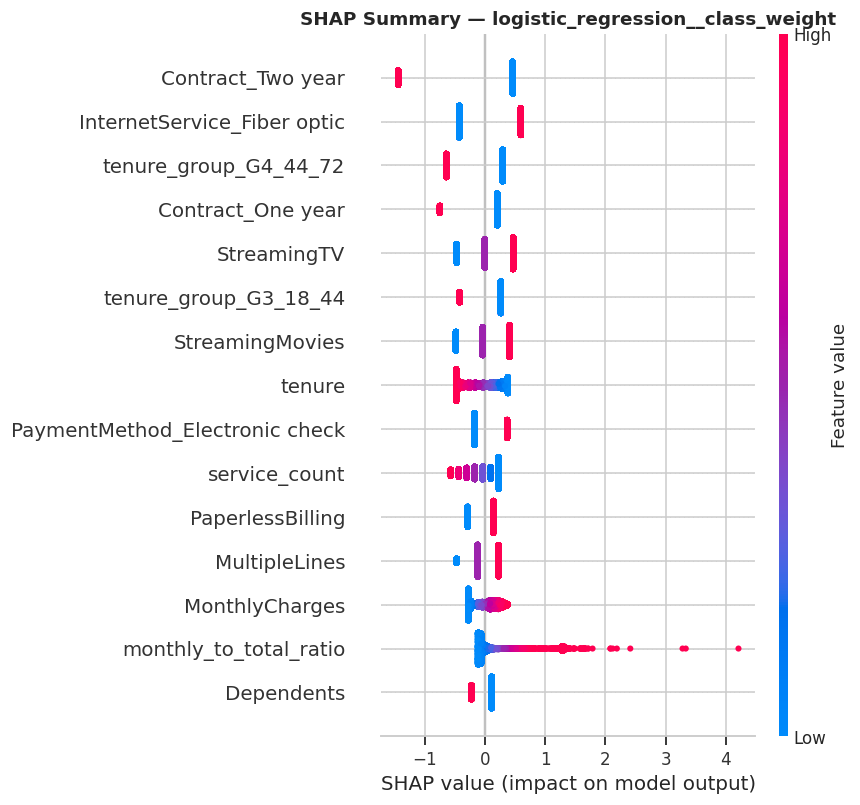


  Model: logistic_regression__smote  [Tier 2]  val_PR-AUC=0.7407
  Computing SHAP values...
  SHAP done dalam 0.0s | shape=(89129, 29)

  D1 — RELEVANCE
    Top-10 parent features: ['Contract', 'InternetService', 'tenure_group', 'StreamingTV', 'tenure', 'StreamingMovies', 'PaymentMethod', 'PaperlessBilling', 'service_count', 'MonthlyCharges']
    Expected features    : ['Contract', 'tenure', 'PaymentMethod', 'InternetService', 'OnlineSecurity']
    Found (4/5)         : ['Contract', 'tenure', 'PaymentMethod', 'InternetService']
    Missing              : ['OnlineSecurity']
    Overlap              : 80% (threshold 50%)
    Verdict              : PASS

  D2 — DIRECTIONALITY
    Fitur dievaluasi: 8
    [OK       ] Contract_One year                        expected=negative actual=negative r=-1.0000
    [OK       ] Contract_Two year                        expected=negative actual=negative r=-1.0000
    [OK       ] tenure                                   expected=negative actual=negative 

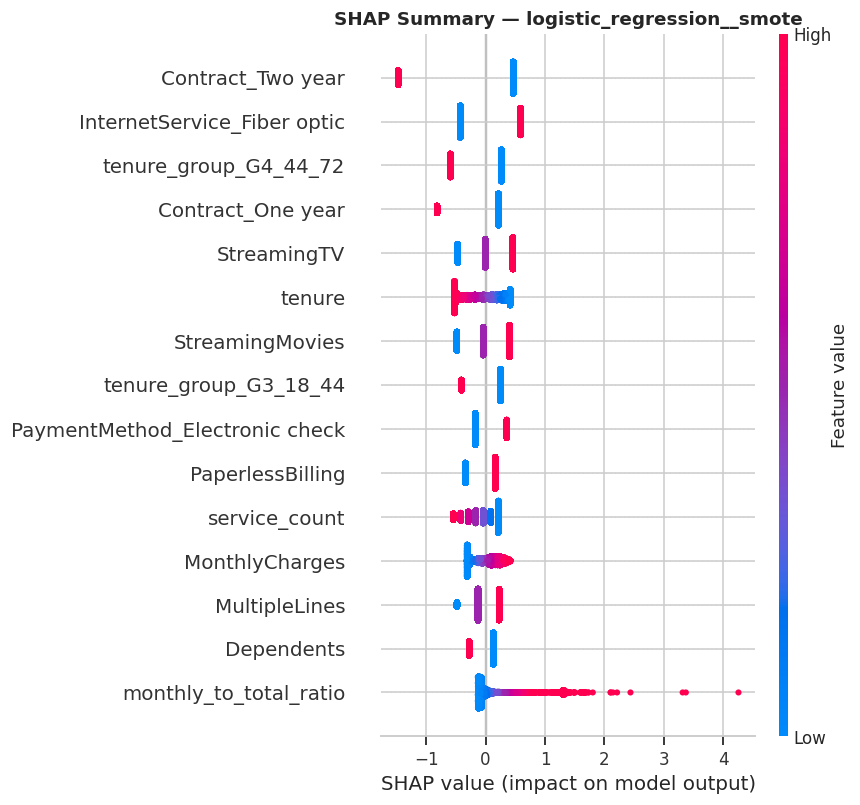

In [14]:
# ════════════════════════════════════════════════════════════════════════════
# MAIN LOOP — evaluasi 8 kandidat
# ════════════════════════════════════════════════════════════════════════════

for cand in CANDIDATES:
    mname   = cand['model_name']
    balance = cand['balance']
    key     = f'{mname}__{balance}'
    model   = loaded_models.get(key)

    print(f'\n{"="*65}')
    print(f'  Model: {key}  [Tier {cand["tier"]}]  val_PR-AUC={cand["val_pr_auc"]}')
    print('='*65)

    if model is None:
        print('  SKIP — model tidak ditemukan')
        continue

    # ── SHAP Computation ────────────────────────────────────────────────────
    print('  Computing SHAP values...')
    import time
    t0         = time.time()
    shap_vals  = SHAPComputer.compute(
        model        = model,
        model_name   = mname,
        X            = X_val,
        feature_names= feature_names
    )
    print(f'  SHAP done dalam {time.time()-t0:.1f}s | shape={shap_vals.shape}')

    # ── D1: Relevance ────────────────────────────────────────────────────────
    print()
    d1_result = d1_checker.check(shap_vals, feature_names)

    # ── D2: Directionality ───────────────────────────────────────────────────
    print()
    # Evaluasi hanya fitur yang ada di top-N actual features (bukan parent)
    top_n_actual = d1_result['shap_importance'].head(XAI_TOP_N).index.tolist()
    d2_result = d2_checker.check(
        shap_values   = shap_vals,
        X             = X_val,
        feature_names = feature_names,
        top_n_features= top_n_actual
    )

    # ── D3: Magnitude ────────────────────────────────────────────────────────
    print()
    d3_result = d3_checker.check(d1_result['shap_importance'])

    # ── D4: Consistency ──────────────────────────────────────────────────────
    print()
    d4_result = d4_checker.check(
        model         = model,
        model_name    = mname,
        shap_values   = shap_vals,
        X_val         = X_val,
        y_val         = y_val,
        feature_names = feature_names
    )

    # ── Scorecard ────────────────────────────────────────────────────────────
    print()
    decision = XAIGateScorecard.decide(
        d1_passed = d1_result['passed'],
        d2_passed = d2_result['passed'],
        d3_passed = d3_result['passed'],
        d4_passed = d4_result['passed']
    )
    jalur_icon = {1: 'JALUR 1', 2: 'JALUR 2', 3: 'JALUR 3'}
    print(f'  SCORECARD  →  {jalur_icon[decision["jalur"]]}: {decision["label"]}')
    print(f'  Optuna trials: {decision["optuna_trials"]}')
    print(f'  Keterangan   : {decision["keterangan"]}')

    # ── Visualisasi SHAP summary ─────────────────────────────────────────────
    fig_title = f'SHAP Summary — {key}'
    plt.figure(figsize=(10, 6))
    shap.summary_plot(
        shap_vals, X_val,
        feature_names = feature_names,
        max_display   = 15,
        show          = False,
        plot_type     = 'dot'
    )
    plt.title(fig_title, fontsize=12, fontweight='bold')
    plt.tight_layout()
    fig_path = os.path.join(OUTPUT_DIR, f'shap_{key}.png')
    plt.savefig(fig_path, bbox_inches='tight', dpi=100)
    plt.show()
    plt.close()

    # ── Simpan ke gate_results ───────────────────────────────────────────────
    gate_results.append({
        'model_name'     : mname,
        'balance'        : balance,
        'tier'           : cand['tier'],
        'val_pr_auc'     : cand['val_pr_auc'],
        # D1
        'd1_passed'      : d1_result['passed'],
        'd1_overlap_pct' : d1_result['overlap_pct'],
        'd1_found'       : d1_result['found_features'],
        'd1_missing'     : d1_result['missing_features'],
        # D2
        'd2_passed'      : d2_result['passed'],
        'd2_n_violations': len(d2_result['violations']),
        'd2_violations'  : d2_result['violations'],
        # D3
        'd3_passed'      : d3_result['passed'],
        'd3_dom_ratio'   : d3_result['dominance_ratio'],
        'd3_cv'          : d3_result['cv'],
        # D4
        'd4_passed'      : d4_result['passed'],
        'd4_mean_spearman': d4_result['mean_spearman'],
        # Gate decision
        'jalur'          : decision['jalur'],
        'jalur_label'    : decision['label'],
        'optuna_trials'  : decision['optuna_trials'],
        'keterangan'     : decision['keterangan'],
        # Artifacts
        'shap_importance': d1_result['shap_importance'],
        'shap_values'    : shap_vals
    })

---
## Ringkasan Hasil XAI Gate #1

In [15]:
print('=== RINGKASAN XAI GATE #1 ===')
print('Diurutkan berdasarkan jalur → val_pr_auc\n')

summary_cols = [
    'model_name', 'balance', 'tier', 'val_pr_auc',
    'd1_passed', 'd1_overlap_pct',
    'd2_passed', 'd2_n_violations',
    'd3_passed', 'd3_dom_ratio', 'd3_cv',
    'd4_passed', 'd4_mean_spearman',
    'jalur', 'jalur_label', 'optuna_trials'
]

summary_df = (
    pd.DataFrame([{k: v for k, v in r.items() if k in summary_cols}
                  for r in gate_results])
    .sort_values(['jalur', 'val_pr_auc'], ascending=[True, False])
    .reset_index(drop=True)
)
display(summary_df.round(4))

=== RINGKASAN XAI GATE #1 ===
Diurutkan berdasarkan jalur → val_pr_auc



,model_name,balance,tier,val_pr_auc,d1_passed,d1_overlap_pct,d2_passed,d2_n_violations,d3_passed,d3_dom_ratio,d3_cv,d4_passed,d4_mean_spearman,jalur,jalur_label,optuna_trials
0,lightgbm,class_weight,1,0.7514,True,0.8000,True,0,True,1.6500,0.7403,True,0.7530,1,PRIORITAS TINGGI,100
1,xgboost,class_weight,1,0.7512,True,0.8000,True,0,True,1.3078,0.6546,True,0.8255,1,PRIORITAS TINGGI,100
2,xgboost,smote,1,0.7479,True,1.0000,True,0,True,1.0536,0.6145,True,0.8153,1,PRIORITAS TINGGI,100
3,lightgbm,smote,1,0.7464,True,0.8000,True,0,True,1.1474,0.6820,True,0.7678,1,PRIORITAS TINGGI,100
4,logistic_regression,class_weight,2,0.7410,True,0.8000,True,0,True,1.5165,0.4289,True,0.8828,1,PRIORITAS TINGGI,100
5,logistic_regression,smote,2,0.7407,True,0.8000,True,0,True,1.5592,0.4297,True,0.8915,1,PRIORITAS TINGGI,100


In [16]:
# ── Breakdown per jalur ───────────────────────────────────────────────────────
print('\n=== BREAKDOWN PER JALUR ===')

for jalur in [1, 2, 3]:
    label_map = {1: 'PRIORITAS TINGGI (100 trials)',
                 2: 'BERSYARAT (30 trials)',
                 3: 'ELIMINASI (0 trials)'}
    group = [r for r in gate_results if r['jalur'] == jalur]
    print(f'\nJalur {jalur} — {label_map[jalur]}: {len(group)} model')
    for r in sorted(group, key=lambda x: x['val_pr_auc'], reverse=True):
        print(f'  {r["model_name"]:25s} ({r["balance"]:12s}) '
              f'| PR-AUC={r["val_pr_auc"]:.4f} '
              f'| D1={"PASS" if r["d1_passed"] else "FAIL"} '
              f'| D2={"PASS" if r["d2_passed"] else "FAIL"} '
              f'| D3={"PASS" if r["d3_passed"] else "FAIL"} '
              f'| D4={"PASS" if r["d4_passed"] else "FAIL"}')
        if r['d2_n_violations'] > 0:
            print(f'    D2 violations: {r["d2_violations"]}')
        if r['d1_missing']:
            print(f'    D1 missing   : {r["d1_missing"]}')


=== BREAKDOWN PER JALUR ===

Jalur 1 — PRIORITAS TINGGI (100 trials): 6 model
  lightgbm                  (class_weight) | PR-AUC=0.7514 | D1=PASS | D2=PASS | D3=PASS | D4=PASS
    D1 missing   : ['OnlineSecurity']
  xgboost                   (class_weight) | PR-AUC=0.7512 | D1=PASS | D2=PASS | D3=PASS | D4=PASS
    D1 missing   : ['OnlineSecurity']
  xgboost                   (smote       ) | PR-AUC=0.7479 | D1=PASS | D2=PASS | D3=PASS | D4=PASS
  lightgbm                  (smote       ) | PR-AUC=0.7464 | D1=PASS | D2=PASS | D3=PASS | D4=PASS
    D1 missing   : ['OnlineSecurity']
  logistic_regression       (class_weight) | PR-AUC=0.7410 | D1=PASS | D2=PASS | D3=PASS | D4=PASS
    D1 missing   : ['OnlineSecurity']
  logistic_regression       (smote       ) | PR-AUC=0.7407 | D1=PASS | D2=PASS | D3=PASS | D4=PASS
    D1 missing   : ['OnlineSecurity']

Jalur 2 — BERSYARAT (30 trials): 0 model

Jalur 3 — ELIMINASI (0 trials): 0 model


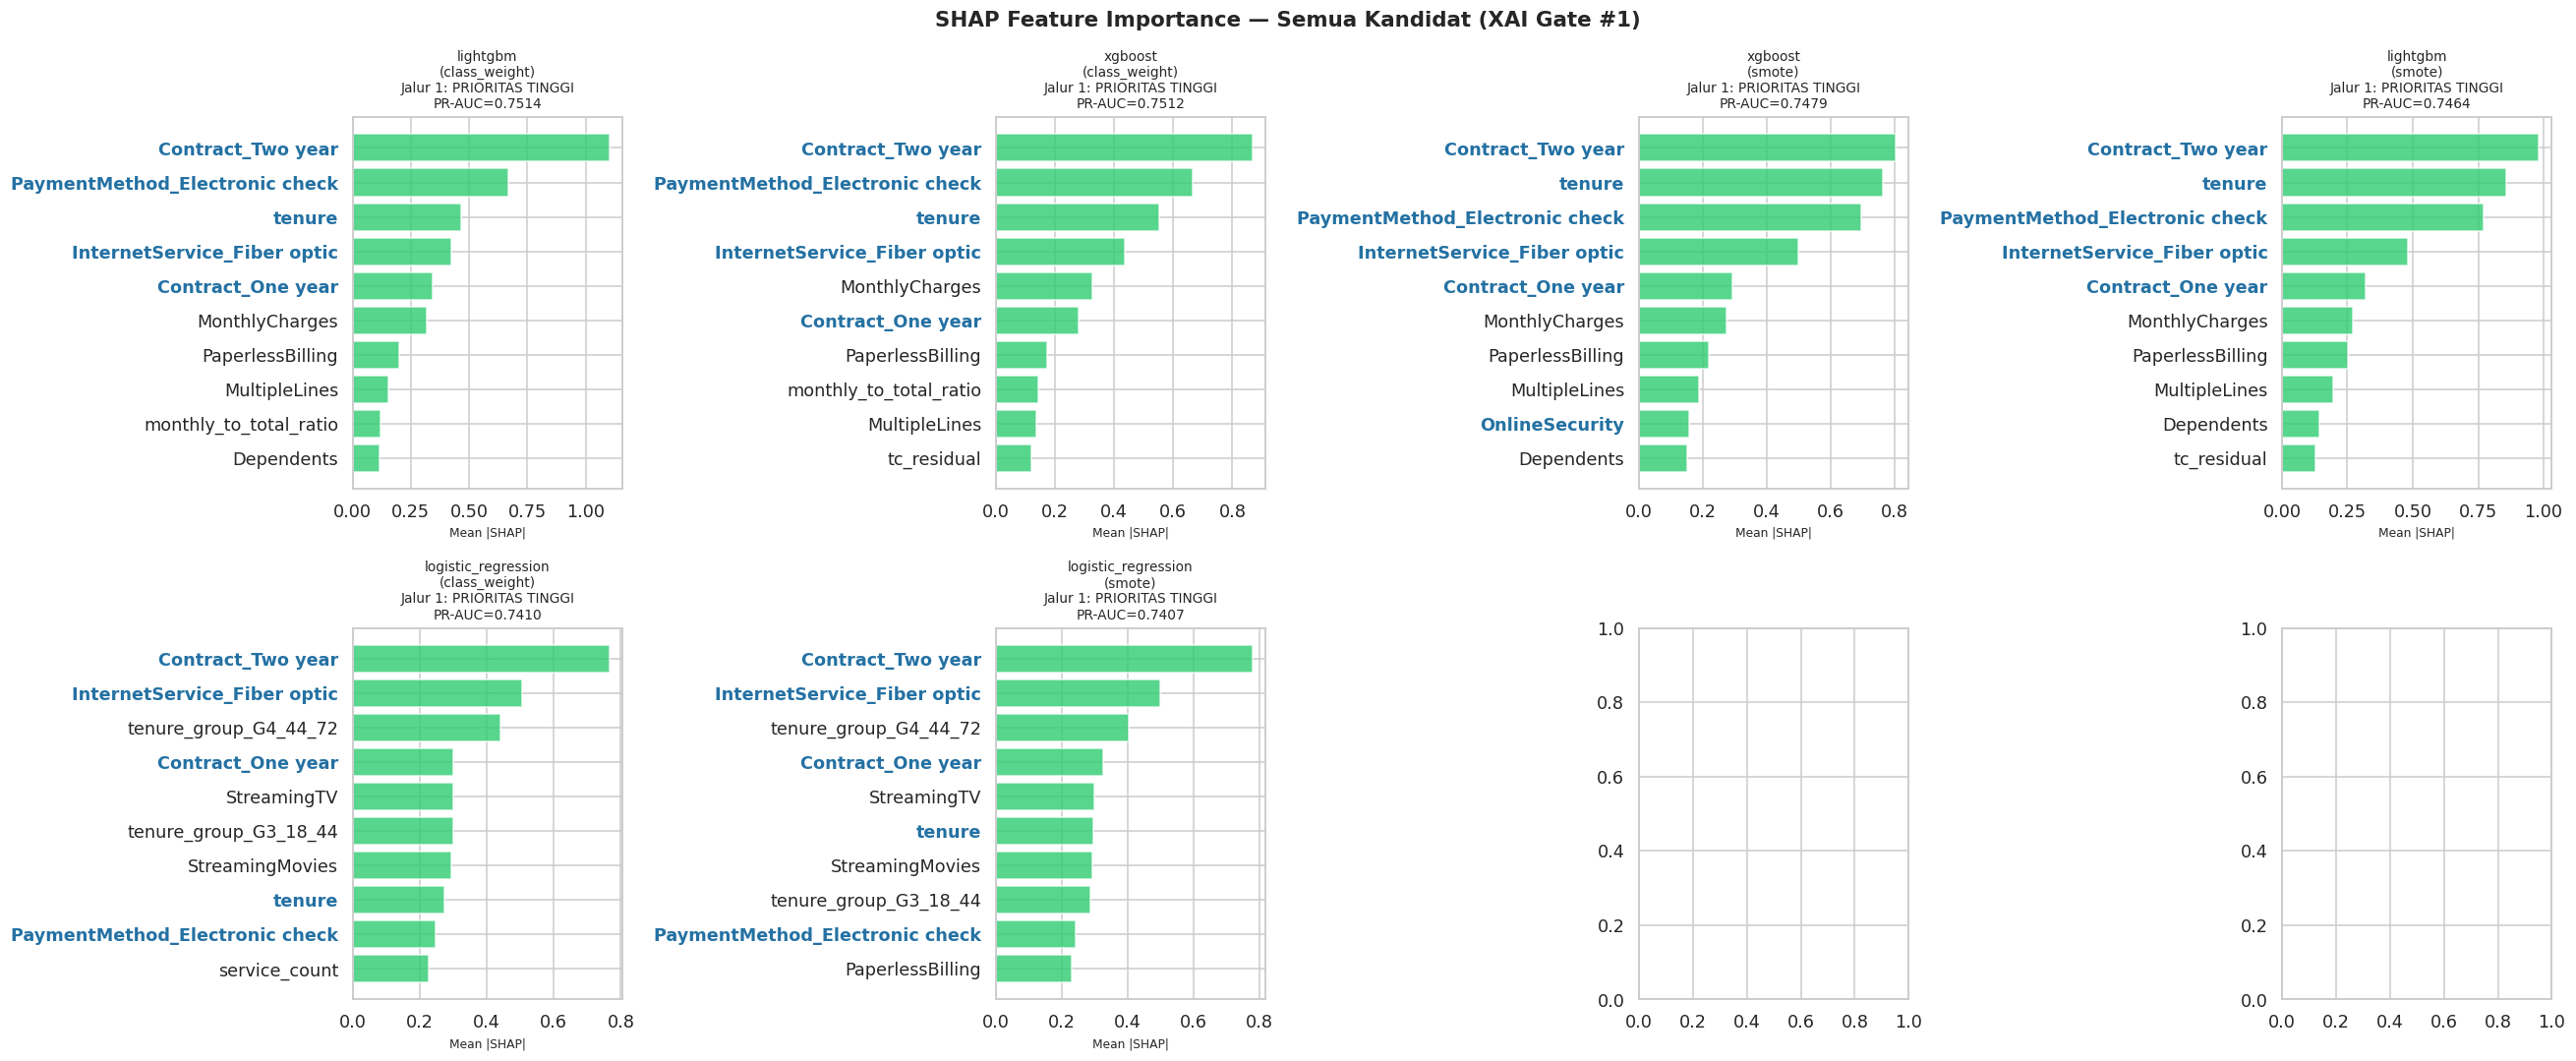

Plot disimpan: /kaggle/working/artifacts/shap_comparison_all_models.png
Catatan: label biru tebal = expected important feature dari EDA Insight 65


In [17]:
# ── Visualisasi SHAP importance comparison (bar chart semua model) ────────────
n_models = len(gate_results)
fig, axes = plt.subplots(2, 4, figsize=(24, 10))
fig.suptitle('SHAP Feature Importance — Semua Kandidat (XAI Gate #1)',
             fontsize=14, fontweight='bold')

axes_flat = axes.flatten()
for idx, r in enumerate(sorted(gate_results, key=lambda x: x['val_pr_auc'], reverse=True)):
    ax      = axes_flat[idx]
    key     = f'{r["model_name"]}\n({r["balance"]})'
    jalur   = r['jalur']
    color   = '#2ecc71' if jalur == 1 else '#f39c12' if jalur == 2 else '#e74c3c'

    # Top 10 fitur
    top10 = r['shap_importance'].head(10)
    ax.barh(top10.index[::-1], top10.values[::-1], color=color, alpha=0.8)
    ax.set_title(f'{key}\nJalur {jalur}: {r["jalur_label"]}\nPR-AUC={r["val_pr_auc"]:.4f}',
                 fontsize=9)
    ax.set_xlabel('Mean |SHAP|', fontsize=8)

    # Tandai expected features dengan bintang
    for ytick in ax.get_yticklabels():
        fname  = ytick.get_text()
        parent = ParentFeatureMapper.to_parent(fname)
        if parent in EXPECTED_IMPORTANT_FEATURES:
            ytick.set_color('#2471a3')
            ytick.set_fontweight('bold')

plt.tight_layout()
fig_path = os.path.join(OUTPUT_DIR, 'shap_comparison_all_models.png')
plt.savefig(fig_path, bbox_inches='tight', dpi=100)
plt.show()
print(f'Plot disimpan: {fig_path}')
print('Catatan: label biru tebal = expected important feature dari EDA Insight 65')

---
## Save Output untuk Notebook Tuning

In [18]:
# ── Buat JSON output untuk notebook 05_tuning ─────────────────────────────────
def make_serializable(obj):
    if isinstance(obj, (np.bool_, bool)):    return bool(obj)
    if isinstance(obj, (np.integer, int)):   return int(obj)
    if isinstance(obj, (np.floating, float)):return float(obj)
    if isinstance(obj, list):                return [make_serializable(i) for i in obj]
    return str(obj)

jalur1 = [r for r in gate_results if r['jalur'] == 1]
jalur2 = [r for r in gate_results if r['jalur'] == 2]
jalur3 = [r for r in gate_results if r['jalur'] == 3]

gate_output = {
    'gate': 'XAI Gate #1 — Baseline',
    'total_candidates'  : len(gate_results),
    'jalur1_count'      : len(jalur1),
    'jalur2_count'      : len(jalur2),
    'jalur3_count'      : len(jalur3),
    'jalur1_models'     : [
        {'model_name': r['model_name'], 'balance': r['balance'],
         'val_pr_auc': make_serializable(r['val_pr_auc']),
         'optuna_trials': 100,
         'd1_overlap': make_serializable(r['d1_overlap_pct']),
         'd4_spearman': make_serializable(r['d4_mean_spearman'])}
        for r in sorted(jalur1, key=lambda x: x['val_pr_auc'], reverse=True)
    ],
    'jalur2_models'     : [
        {'model_name': r['model_name'], 'balance': r['balance'],
         'val_pr_auc': make_serializable(r['val_pr_auc']),
         'optuna_trials': 30,
         'd3_passed': make_serializable(r['d3_passed']),
         'd4_passed': make_serializable(r['d4_passed'])}
        for r in sorted(jalur2, key=lambda x: x['val_pr_auc'], reverse=True)
    ],
    'jalur3_eliminated' : [
        {'model_name': r['model_name'], 'balance': r['balance'],
         'd1_passed': make_serializable(r['d1_passed']),
         'd2_passed': make_serializable(r['d2_passed']),
         'd2_violations': make_serializable(r['d2_violations'])}
        for r in jalur3
    ]
}

output_path = os.path.join(OUTPUT_DIR, 'xai_gate1_results.json')
with open(output_path, 'w') as f:
    json.dump(gate_output, f, indent=2)
print(f'OK gate results disimpan: {output_path}')

# Print ringkasan JSON
print(json.dumps({k: v for k, v in gate_output.items()
                  if k not in ('jalur1_models','jalur2_models','jalur3_eliminated')},
                 indent=2))

OK gate results disimpan: /kaggle/working/artifacts/xai_gate1_results.json
{
  "gate": "XAI Gate #1 \u2014 Baseline",
  "total_candidates": 6,
  "jalur1_count": 6,
  "jalur2_count": 0,
  "jalur3_count": 0
}


---
## Ringkasan Final

In [19]:
import glob

print('=' * 65)
print('  XAI GATE #1 SELESAI')
print('=' * 65)
print()
print(f'  Total kandidat dievaluasi : {len(gate_results)}')
print(f'  Jalur 1 (Prioritas Tinggi): {len(jalur1)} model → 100 Optuna trials')
print(f'  Jalur 2 (Bersyarat)       : {len(jalur2)} model → 30 Optuna trials')
print(f'  Jalur 3 (Eliminasi)       : {len(jalur3)} model → tidak masuk tuning')
print()
if jalur1:
    print('  Jalur 1 — Model prioritas:')
    for r in sorted(jalur1, key=lambda x: x['val_pr_auc'], reverse=True):
        print(f'    {r["model_name"]:25s} ({r["balance"]})')
if jalur2:
    print('\n  Jalur 2 — Model bersyarat:')
    for r in sorted(jalur2, key=lambda x: x['val_pr_auc'], reverse=True):
        miss = 'D3' if not r['d3_passed'] else ''
        miss += '+D4' if not r['d4_passed'] else ''
        print(f'    {r["model_name"]:25s} ({r["balance"]}) | gagal: {miss}')
if jalur3:
    print('\n  Jalur 3 — Dieliminasi:')
    for r in jalur3:
        reason = []
        if not r['d1_passed']: reason.append('D1')
        if not r['d2_passed']: reason.append(f'D2 [{r["d2_violations"]}]')
        print(f'    {r["model_name"]:25s} ({r["balance"]}) | {" + ".join(reason)}')
print()
print('Artifacts:')
for f in sorted(glob.glob(f'{OUTPUT_DIR}/*.json') +
                glob.glob(f'{OUTPUT_DIR}/*.png') +
                glob.glob(f'{OUTPUT_DIR}/*.csv')):
    kb = os.path.getsize(f) / 1024
    print(f'  {os.path.basename(f):50s} ({kb:.0f} KB)')
print()
print('Langkah berikutnya: 05_tuning/')
print('  Jalur 1 → Optuna 100 trials')
print('  Jalur 2 → Optuna 30 trials + review XAI ulang')

  XAI GATE #1 SELESAI

  Total kandidat dievaluasi : 6
  Jalur 1 (Prioritas Tinggi): 6 model → 100 Optuna trials
  Jalur 2 (Bersyarat)       : 0 model → 30 Optuna trials
  Jalur 3 (Eliminasi)       : 0 model → tidak masuk tuning

  Jalur 1 — Model prioritas:
    lightgbm                  (class_weight)
    xgboost                   (class_weight)
    xgboost                   (smote)
    lightgbm                  (smote)
    logistic_regression       (class_weight)
    logistic_regression       (smote)

Artifacts:
  shap_comparison_all_models.png                     (159 KB)
  shap_lightgbm__class_weight.png                    (97 KB)
  shap_lightgbm__smote.png                           (94 KB)
  shap_logistic_regression__class_weight.png         (77 KB)
  shap_logistic_regression__smote.png                (76 KB)
  shap_xgboost__class_weight.png                     (93 KB)
  shap_xgboost__smote.png                            (93 KB)
  xai_gate1_results.json                            